In [91]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [92]:
df = pd.read_csv('/PyAi/tvmarketing.csv')
df.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [93]:
df.shape

(200, 2)

In [94]:
df.isnull().sum()

TV       0
Sales    0
dtype: int64

In [95]:
df.duplicated().sum()

np.int64(0)

<function matplotlib.pyplot.show(close=None, block=None)>

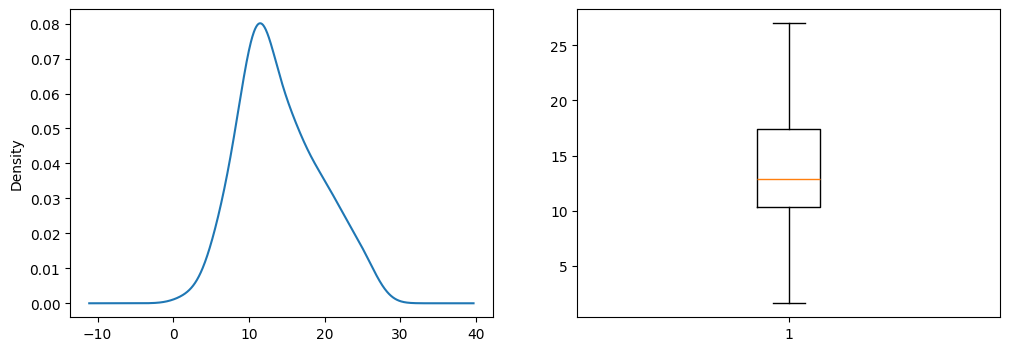

In [96]:
f = plt.figure(figsize=(12,4))
f.add_subplot(1,2,1)
df['Sales'].plot(kind='kde')
f.add_subplot(1,2,2)
plt.boxplot(df['Sales'])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

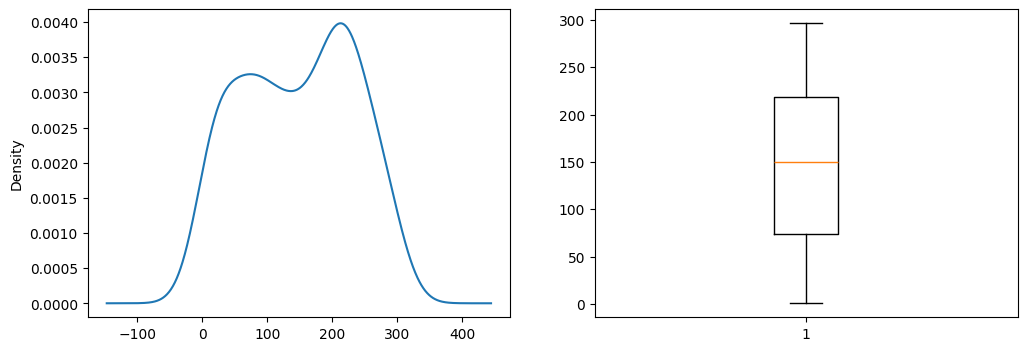

In [97]:
f = plt.figure(figsize=(12,4))
f.add_subplot(1,2,1)
df['TV'].plot(kind='kde')
f.add_subplot(1,2,2)
plt.boxplot(df['TV'])
plt.show

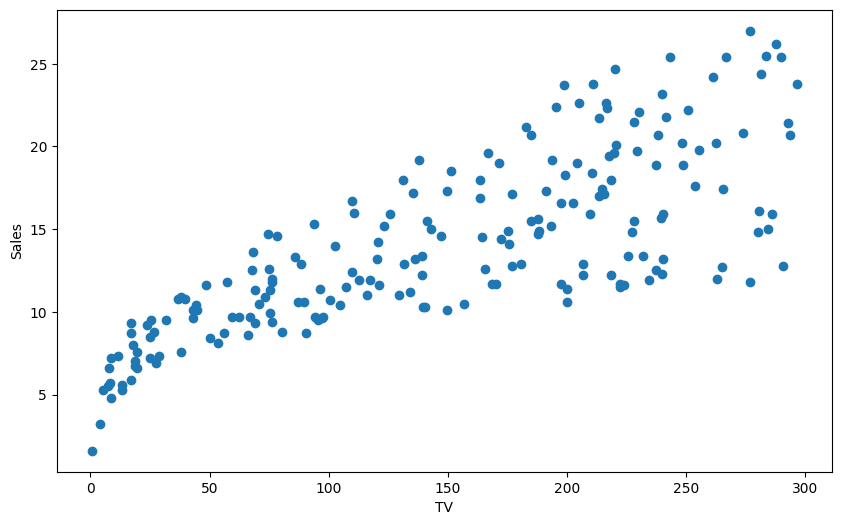

In [98]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(df['TV'], df['Sales'])
ax.set_xlabel('TV')
ax.set_ylabel('Sales')
plt.show()

In [99]:
df[['TV','Sales']].corr()

,TV,Sales
TV,1.000000,0.782224
Sales,0.782224,1.000000


In [100]:
def mean(values):
    return sum(values) / len(values)

def std(values):
    mean_val = mean(values)
    return (sum((x - mean_val) ** 2 for x in values) / len(values)) ** 0.5

In [101]:
mean_tv = df['TV'].mean()
mean_sales = df['Sales'].mean()

In [123]:
#hitung korelasi
correlation = sum((x - mean_tv) * (y - mean_sales) for x, y in zip(df['TV'], df['Sales'])) / (len (df['TV']) * std (df['TV']) * std(df['Sales']))
print("korelasi tv dan sales:", correlation)

korelasi tv dan sales: 0.7822244248616063


In [143]:
#koefisiensi regresi
numerator = sum((x - mean_tv) * (y - mean_sales) for x, y in zip(df['TV'], df['Sales']))
denominator = sum((x - mean_tv) ** 2 for x in df['TV'])

In [144]:
# hitung slope
slope = numerator / denominator
intercept = mean_sales - slope * mean_tv

In [145]:
#funhssi prediksi
def predict(x):
    return slope * x + intercept

In [146]:
#cetak hasil slope dn intercept
print("Slope (b1):", slope)
print("Intercept (b0):", intercept)

Slope (b1): 0.04753664043301969
Intercept (b0): 7.032593549127704


In [147]:
def mae(predictions, targets):
    return sum(abs(p - t) for p, t in zip(predictions, targets)) / len(targets)

def mse(predictions, targets):
    return sum((p - t) ** 2 for p, t in zip(predictions, targets)) / len(targets)

def rmse(predictions, targets):
    return (mse(predictions, targets)) ** 0.5

In [148]:
predictions = [predict(x) for x in df['TV']]

In [149]:
mae_value = mae(predictions, df['Sales'])
mse_value = mse(predictions, df['Sales'])
rmse_value = rmse(predictions, df['Sales'])

In [150]:
#rsq
sst = sum((y - mean_sales) ** 2 for y in df['Sales'])
ssr = sum((p - y) ** 2 for p, y in zip(predictions, df['Sales']))
r_squared_value = 1 - (ssr / sst)          

In [151]:
print("MAE:", mae_value)
print("MSE:", mse_value)
print("RMSE:", rmse_value)
print("R-squared:", r_squared_value)

MAE: 2.5498060389274864
MSE: 10.512652915656759
RMSE: 3.2423221486546887
R-squared: 0.6118750508500708


In [152]:
dataset = {
    "TV (X)": df['TV'],
    "Sales (y)": df['Sales'],
    "Predicted Sales": predictions,
}

In [153]:
# Membuat DataFrame
df_dataset = pd.DataFrame(dataset)

# Mencetak DataFrame
print(df_dataset)

     TV (X)  Sales (y)  Predicted Sales
0     230.1       22.1        17.970775
1      44.5       10.4         9.147974
2      17.2        9.3         7.850224
3     151.5       18.5        14.234395
4     180.8       12.9        15.627218
..      ...        ...              ...
195    38.2        7.6         8.848493
196    94.2        9.7        11.510545
197   177.0       12.8        15.446579
198   283.6       25.5        20.513985
199   232.1       13.4        18.065848

[200 rows x 3 columns]


In [154]:
result = pd.DataFrame(dataset)
print(result.head())

   TV (X)  Sales (y)  Predicted Sales
0   230.1       22.1        17.970775
1    44.5       10.4         9.147974
2    17.2        9.3         7.850224
3   151.5       18.5        14.234395
4   180.8       12.9        15.627218


In [155]:
result['Residual'] = result['Sales (y)'] - result['Predicted Sales']

In [156]:
result[['TV (X)','Sales (y)','Predicted Sales','Residual']]

,TV (X),Sales (y),Predicted Sales,Residual
0,230.1,22.1,17.970775,4.129225
1,44.5,10.4,9.147974,1.252026
2,17.2,9.3,7.850224,1.449776
3,151.5,18.5,14.234395,4.265605
4,180.8,12.9,15.627218,-2.727218
...,...,...,...,...
195,38.2,7.6,8.848493,-1.248493
196,94.2,9.7,11.510545,-1.810545
197,177.0,12.8,15.446579,-2.646579
198,283.6,25.5,20.513985,4.986015


,TV,Sales
TV,1.000000,0.782224
Sales,0.782224,1.000000


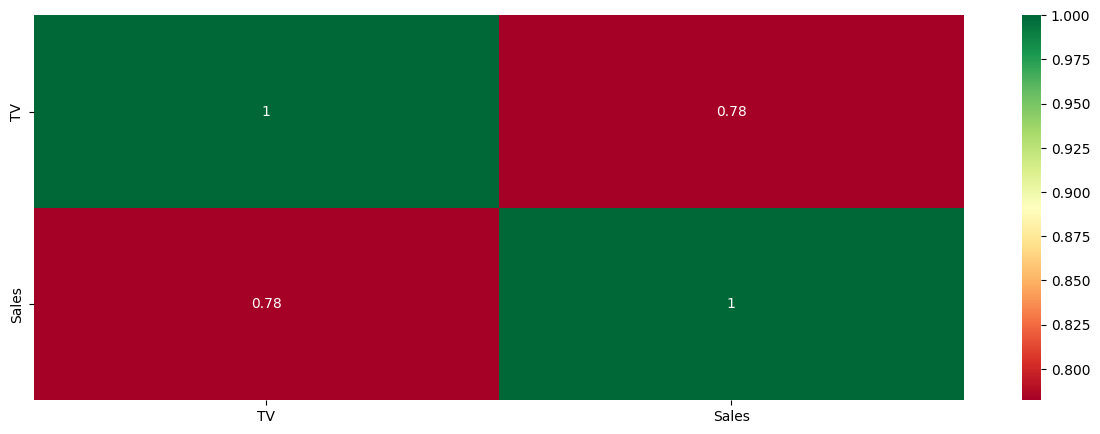

In [157]:
plt.figure(figsize=(15,5))
c = df.corr(numeric_only=True)
sns.heatmap(c, cmap="RdYlGn", annot=True)
c

In [158]:
def train_test_split_np(X, y, test_size=0.2, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(X))
    rng.shuffle(idx)
    n_test = int(len(X) * test_size)
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X = df["TV"].to_numpy()
y = df["Sales"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split_np(X, y, test_size=0.2, seed=42)
len(X_train), len(X_test)

(160, 40)

In [161]:
mean_x = np.mean(X_train)
mean_y = np.mean(y_train)

numerator = np.sum((X_train - mean_x) * (y_train - mean_y))
denominator = np.sum((X_train - mean_x) ** 2)

b1 = numerator / denominator
b0 = mean_y - b1 * mean_x

In [162]:
def predict_sales(tv):
    return b0 + b1 * tv

In [164]:
#harga prediksi untuk TV
samples = [50]

for s in samples:
    print("TV:", s, "-> Predicted Sales:", predict_sales(s))

TV: 50 -> Predicted Sales: 9.455411979940303


In [166]:
#prediksi akurasi
def test_tv_sales(tv, actual_sales):
    pred = predict_sales(tv)
    
    error = abs(actual_sales - pred)
    accuracy = (1 - (error / actual_sales)) * 100
    
    print("TV:", tv)
    print("Actual Sales:", actual_sales)
    print("Predicted Sales:", pred)
    print("Error:", error)
    print("Accuracy:", accuracy, "%")

In [180]:
test_tv_sales(150, 15)

TV: 150
Actual Sales: 15
Predicted Sales: 14.310448403353051
Error: 0.6895515966469485
Accuracy: 95.40298935568701 %


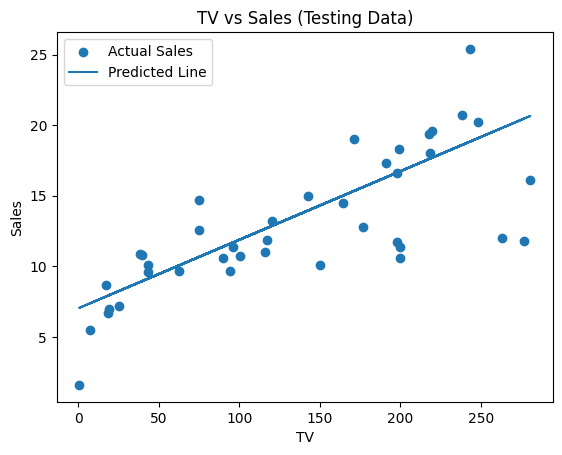

In [181]:
y_pred = b0 + b1 * X_test

plt.scatter(X_test, y_test, label="Actual Sales")
plt.plot(X_test, y_pred, label="Predicted Line")

plt.xlabel("TV")
plt.ylabel("Sales")
plt.title("TV vs Sales (Testing Data)")
plt.legend()

plt.show()